In [ ]:
!wc -l "/content/drive/MyDrive/score-estimation-model/data/pred/pred_1023_10k_uniform_with_mig.csv"

10073 /content/drive/MyDrive/score-estimation-model/data/pred/pred_1023_10k_uniform_with_mig.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!head -10 "/content/drive/MyDrive/score-estimation-model/data/pred/pred_training_data.csv"

average,blobRead,decisionTree,errorEstimate,mqttPublish,multiVarLinearReg,senMLParse,sink,source,metricScore,migrationCost
915,1375,1629,470,1630,1176,209,327,1881,193.0,2283.0
440,1620,1523,1963,1590,2027,1138,10,1232,59.0,2162.0
469,469,85,1145,1273,1087,89,342,1477,304.0,2142.0
333,1039,2027,1071,773,1683,220,1998,425,435.0,1932.0
2019,1477,531,1098,1791,1884,472,1276,183,98.0,2049.0
29,665,1740,1979,791,1279,28,1160,1088,135.0,2158.0
655,182,1365,1980,931,1703,323,353,1995,311.0,2150.0
1941,95,257,1621,223,1391,393,208,1893,431.0,2271.0
250,987,1588,1379,360,1307,843,1598,227,226.0,1573.0


# Train on Training Set, then adapt to specific domain by training on a few extra samples from the new domain

In [ ]:
!pip show xgboost

In [ ]:
!pip install paretoset

In [ ]:
# Import necessary libraries
from xgboost import XGBRegressor
from paretoset import paretoset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
def print_comparison_results(title, pre_metrics, post_metrics):
  # Adjust the total width for alignment
  total_width = 75
  separator = '*' * total_width
  header_width = 25  # Adjust the column width for better alignment

  print(separator)
  print(f"{title:^{total_width}}")
  print(separator)
  print(f"{'Metric':<15}{'Before Tuning (X_test)':^{header_width}}{'After Tuning (X_unseen)':^{header_width}}")
  print('-' * total_width)
  for metric_name, pre_value, post_value in zip(
      ["MSE", "MAE", "R^2", "Spearman"], pre_metrics, post_metrics
  ):
      print(f"{metric_name:<15}{pre_value:^{header_width}.2f}{post_value:^{header_width}.2f}")
  print('\n')

In [ ]:
def get_eval_metrics(x, y):
  mse = mean_squared_error(x, y)
  mae = mean_absolute_error(x, y)
  r2 = r2_score(x, y)
  spearman_corr, _ = spearmanr(x, y)
  return [mse, mae, r2, spearman_corr]


In [ ]:
def initialize_model():
  """
  Method to inialize an xgb regressor
  """
  return XGBRegressor(
    booster='gbtree',
    n_estimators=500,          # Reduced to avoid overfitting
    learning_rate=0.05,        # Lower learning rate for stability
    max_depth=3,               # Reduced depth for simplicity
    subsample=0.8,             # Use subsampling to generalize better
    colsample_bytree=0.8,      # Column subsampling to reduce feature dependency
    reg_alpha=0.5,             # Increased L1 regularization
    reg_lambda=3.0,            # Increased L2 regularization
    random_state=42
  )

In [ ]:
# Load the data (training and domain adaptation)
adaptation_network = 2047
workflow_name = 'pred'
training_data = pd.read_csv(f'/content/drive/MyDrive/score-estimation-model/data/{workflow_name}/{workflow_name}_training_data.csv')
unseen_data = pd.read_csv(f'/content/drive/MyDrive/score-estimation-model/data/{workflow_name}/{workflow_name}_{adaptation_network}_10k_uniform_with_mig.csv')
unseen_data.head(5)

,average,blobRead,decisionTree,errorEstimate,mqttPublish,multiVarLinearReg,senMLParse,sink,source,metricScore,migrationCost
0,1920,995,1023,1275,1101,1637,160,1149,811,716.0,1803.0
1,1787,453,1118,1289,183,1929,829,2019,1196,228.0,2021.0
2,208,1781,296,1522,222,1609,1606,948,758,298.0,1585.0
3,1187,681,362,1226,1654,749,1625,79,830,285.0,1807.0
4,832,1019,1239,191,406,848,80,1702,1157,252.0,1928.0


In [ ]:
print(f'Building models for: {workflow_name.upper()}')
print(f'Domain adaptation network: {adaptation_network}')
print()

# Split into features and target
X = training_data.drop(columns=['metricScore', 'migrationCost'])
y_metric_score = training_data['metricScore']
y_migration_cost = training_data['migrationCost']

# Split the data into train/test sets
X_train, X_test, y_metric_score_train, y_metric_score_test = train_test_split(X, y_metric_score, test_size=0.2, random_state=42)
_, _, y_migration_cost_train, y_migration_cost_test = train_test_split(X, y_migration_cost, test_size=0.2, random_state=42)

# Load the unseen data
X_unseen = unseen_data.drop(columns=['metricScore', 'migrationCost'])
y_unseen_metric_score_actual = unseen_data['metricScore']
y_unseen_migration_cost_actual = unseen_data['migrationCost']


# Initialize the XGBoost model with updated regularization parameters
# MODEL FOR PREDICTING THE METRIC SCORE
xgb_metric_score_model = initialize_model()

# Initialize the XGBoost model with updated regularization parameters
# MODEL FOR PREDICTING THE MIGRATION COST
xgb_migration_cost_model = initialize_model()

# Assertions for java compatibility and thread safety purposes
assert xgb_migration_cost_model.get_params()['booster'] == 'gbtree'
assert xgb_metric_score_model.get_params()['booster'] == 'gbtree'

# FIRST TRAIN ON THE REGULAR TRAINING DATASET
# Metric score model
initial_score_model = xgb_metric_score_model.fit(
      X_train, y_metric_score_train,
      verbose=False
  )

# Migration cost model
initial_migration_cost_model = xgb_migration_cost_model.fit(
      X_train, y_migration_cost_train,
      verbose=False
  )


# At this point the model is trained with the original training data.
# Time to evaluate it
y_metric_score_pred = initial_score_model.predict(X_test)
initial_score_metrics = get_eval_metrics(y_metric_score_test, y_metric_score_pred)

y_migration_cost_pred = initial_migration_cost_model.predict(X_test)
initial_migration_cost_metrics = get_eval_metrics(y_migration_cost_test, y_migration_cost_pred)


# PERFORM DOMAIN ADAPTATION ON BOTH MODELS
# First split the X_unseen data to domain adaptation train data and test data
test_size = 0.01
print(f'TEST SIZE: {test_size}')
X_unseen_train, X_unseen_test, y_unseen_score_train, y_unseen_score_test = train_test_split(X_unseen, y_unseen_metric_score_actual, test_size=test_size, random_state=42 )
_, _, y_unseen_migration_cost_train, y_unseen_migration_cost_test = train_test_split(X_unseen, y_unseen_migration_cost_actual, test_size=test_size, random_state=42 )


print("Perform domain adaptation on both models")
fine_tuned_score_model = initial_score_model.fit(
    X_unseen_train,
    y_unseen_score_train,
    verbose=False,
    xgb_model=initial_score_model.get_booster()
)

fine_tuned_migration_cost_model = initial_migration_cost_model.fit(
    X_unseen_train,
    y_unseen_migration_cost_train,
    verbose=False,
    xgb_model=initial_migration_cost_model.get_booster()
)

# Predict the unseen data
y_metric_score_unseen_pred = fine_tuned_score_model.predict(X_unseen_test)
fine_tuned_score_metrics = get_eval_metrics(y_unseen_score_test, y_metric_score_unseen_pred)

y_migration_cost_unseen_pred = fine_tuned_migration_cost_model.predict(X_unseen_test)
fine_tuned_migration_cost_metrics = get_eval_metrics(y_unseen_migration_cost_test, y_migration_cost_unseen_pred)

print_comparison_results('METRIC SCORE', initial_score_metrics, fine_tuned_score_metrics)
print_comparison_results('MIGRATION COST', initial_migration_cost_metrics, fine_tuned_migration_cost_metrics)

total_score_unseen_actual = y_unseen_score_test - y_unseen_migration_cost_test
total_score_unseen_pred =  y_metric_score_unseen_pred - y_migration_cost_unseen_pred

spearman_corr, _ = spearmanr(total_score_unseen_actual, total_score_unseen_pred)
print(f'Total score (metric_score - migration_cost) Spearman Coef: {spearman_corr:.4f}')



Building models for: PRED
Domain adaptation network: 2047

TEST SIZE: 0.01
Perform domain adaptation on both models
***************************************************************************
                               METRIC SCORE                                
***************************************************************************
Metric          Before Tuning (X_test)   After Tuning (X_unseen) 
---------------------------------------------------------------------------
MSE                    23885.18                 16729.06         
MAE                     122.95                   100.46          
R^2                      0.29                     0.41           
Spearman                 0.55                     0.70           


***************************************************************************
                              MIGRATION COST                               
***************************************************************************
Metric          Befo

In [ ]:
fine_tuned_score_model.save_model(f'/content/drive/MyDrive/score-estimation-model/models/{workflow_name}/{workflow_name}_{adaptation_network}_score_model.bin')
fine_tuned_migration_cost_model.save_model(f'/content/drive/MyDrive/score-estimation-model/models/{workflow_name}/{workflow_name}_{adaptation_network}_migration_cost_model.bin')


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:16:50] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


Index([5719, 9829, 7888, 43, 4744, 9429], dtype='int64')
Index([8596, 402, 2663, 497, 43, 7320, 3630], dtype='int64')
Intersection: {43}
Overlap: 0.17
Dice: 0.15
Percentage of similar items in real data (intersection / pareto_real): 16.67%
Percentage of similar items in predicted data (intersection / pareto_predicted): 14.29%
Jaccard Index: 0.08


<ipython-input-28-c739c9b6e349>:37: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


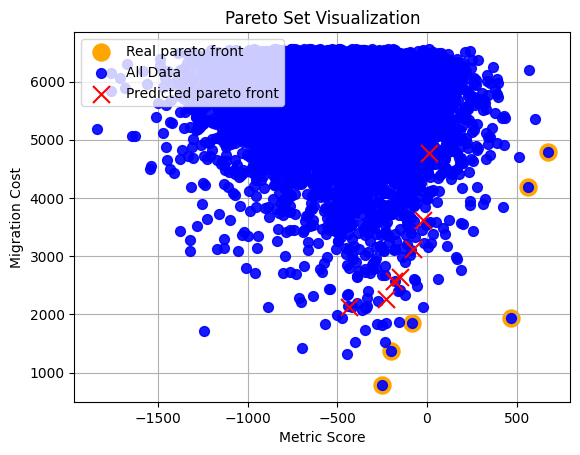

In [ ]:
real_data = pd.DataFrame({'metricScore' : y_unseen_score_test, 'migrationCost' : y_unseen_migration_cost_test})
predicted_data = pd.DataFrame({'metricScore' : y_metric_score_unseen_pred, 'migrationCost' : y_migration_cost_unseen_pred}, index=real_data.index)


# print(type(y_unseen_migration_cost_test))
mask_real = paretoset(real_data, sense=["max", "min"])
paretoset_real_data = real_data[mask_real]
print(paretoset_real_data.index)

mask_predicted = paretoset(predicted_data, sense=["max", "min"])
paretoset_predicted_data = predicted_data[mask_predicted]
print(paretoset_predicted_data.index)

# Plot Pareto-optimal points in the background
plt.scatter(
    paretoset_real_data["metricScore"],
    paretoset_real_data["migrationCost"],
    color="orange",  # Orange background points
    edgecolor="orange",  # Optional border for distinction
    s=150,  # Larger size for visibility
    label="Real pareto front",
    zorder=1  # Background layer
)


# Plot all data points in the foreground
plt.scatter(
    real_data["metricScore"],
    real_data["migrationCost"],
    label="All Data",
    color="blue",  # Blue points in foreground
    s=50,  # Smaller size for visibility
    alpha=0.9,
    zorder=2  # Foreground layer
)

plt.scatter(
    paretoset_predicted_data["metricScore"],
    paretoset_predicted_data["migrationCost"],
    color="red",  # Orange background points
    edgecolor="red",  # Optional border for distinction
    marker='x',
    s=150,  # Larger size for visibility
    label="Predicted pareto front",
    zorder=2  # Background layer
)

# Add labels and title
plt.title("Pareto Set Visualization")
plt.xlabel("Metric Score")
plt.ylabel("Migration Cost")

# Add legend in the top-left corner
plt.legend(loc="upper left")
plt.grid(True)

pareto_set_real_points = set(paretoset_real_data.index)
pareto_set_predicted_points = set(paretoset_predicted_data.index)

# Calculate the intersection
intersection = pareto_set_real_points & pareto_set_predicted_points
print(f'Intersection: {intersection}')

# Percentage of similar items in each set
percentage_real = len(intersection) / len(pareto_set_real_points) * 100
percentage_predicted = len(intersection) / len(pareto_set_predicted_points) * 100

# Jaccard index
jaccard_index = len(intersection) / len(pareto_set_real_points | pareto_set_predicted_points)
dice = 2 * len(intersection) / (len(pareto_set_real_points) + len(pareto_set_predicted_points))
overlap  = len(intersection) / min(len(pareto_set_real_points) , len(pareto_set_predicted_points))

print(f'Overlap: {overlap:.2f}')
print(f'Dice: {dice:.2f}')

# Display results
print(f"Percentage of similar items in real data (intersection / pareto_real): {percentage_real:.2f}%")
print(f"Percentage of similar items in predicted data (intersection / pareto_predicted): {percentage_predicted:.2f}%")
print(f"Jaccard Index: {jaccard_index:.2f}")


In [ ]:

# Try to train the SCORE MODEL with extra synthetic data from the unseen dataset
# Generate synthetic unseen-like data based on column-wise unseen data statistics
# print("Generating synthetic unseen-like data column-wise...")

# # Number of synthetic samples
# num_samples = 10000

# # Initialize an empty DataFrame to store synthetic data
# synthetic_unseen = pd.DataFrame()

# # Generate synthetic data for each column separately
# for column in X_unseen.columns:
#     column_mean = X_unseen[column].mean()
#     column_std = X_unseen[column].std()
#     synthetic_column = np.random.normal(loc=column_mean, scale=column_std, size=num_samples)
#     synthetic_unseen[column] = synthetic_column

# unseen_score_mean = y_unseen_metric_score_actual.mean()
# unseen_score_std = y_unseen_metric_score_actual.std()
# synthetic_scores = np.random.normal(loc=column_mean, scale=column_std, size=num_samples)

# print("Train the initial score model with the synthetic data...")
# synthetic_tuned_score_model = initial_score_model.fit(
#     synthetic_unseen,
#     synthetic_scores,
#     verbose=False,
#     xgb_model=initial_score_model.get_booster()
# )

In [ ]:
# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
spearman_scores = []
mae_scores = []

print("Performing cross-validation with augmented data...")
for train_idx, val_idx in kf.split(X_augmented):
    # Create train and validation sets for this fold
    X_tr, X_val = X_augmented.iloc[train_idx], X_augmented.iloc[val_idx]
    y_tr, y_val = y_augmented.iloc[train_idx], y_augmented.iloc[val_idx]

    # Fit the model
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],  # Validation set
        verbose=False              # Suppress training logs
    )

    # Make predictions on the validation set
    y_val_pred = xgb_model.predict(X_val)

    # Evaluate Spearman correlation and MAE on validation set
    spearman_corr, _ = spearmanr(y_val, y_val_pred)
    mae = mean_absolute_error(y_val, y_val_pred)
    spearman_scores.append(spearman_corr)
    mae_scores.append(mae)

# Print cross-validation results
print(f"Cross-Validation Spearman Correlation: {np.mean(spearman_scores):.4f} ± {np.std(spearman_scores):.4f}")
print(f"Cross-Validation MAE: {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")

# Train the model on the full augmented dataset
print("Training on the full augmented dataset...")
xgb_model.fit(
    X_augmented, y_augmented,
    eval_set=[(X_test, y_test)],  # Test set as validation during training
    verbose=False
)

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model on the test set
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
spearman_corr, _ = spearmanr(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")


In [ ]:
simport joblib
joblib.dump(xgb_model, '/content/drive/MyDrive/score-estimation-model/models/fine_tuned_xgb_model_7_train.pkl')
xgb_model.save_model('/content/drive/MyDrive/score-estimation-model/models/fine_tuned_xgb_model_7_train.bin')


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:44:10] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


# What if we trained only on unseen data?

In [ ]:
from sklearn.model_selection import train_test_split

# Split unseen data into 80% training and 20% testing
print("Splitting unseen data into training and testing subsets...")
X_unseen_train, X_unseen_test, y_unseen_train, y_unseen_test = train_test_split(
    X_unseen[:300], y_actual[:300], test_size=0.2, random_state=42
)

# Train the model on the unseen training subset
print("Training XGBoost model on unseen training subset...")
xgb_model_unseen_split = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=3.0,
    random_state=42
)

xgb_model_unseen_split.fit(X_unseen_train, y_unseen_train)

# Evaluate the model on the unseen testing subset
print("Evaluating on the unseen testing subset...")
y_unseen_test_pred = xgb_model_unseen_split.predict(X_unseen_test)
spearman_corr_unseen_test, _ = spearmanr(y_unseen_test, y_unseen_test_pred)
mae_unseen_test = mean_absolute_error(y_unseen_test, y_unseen_test_pred)

print(f"Spearman Correlation (Unseen Testing Subset): {spearman_corr_unseen_test:.4f}")
print(f"MAE (Unseen Testing Subset): {mae_unseen_test:.2f}")

# Evaluate the model on the original test set
print("Evaluating on the original test set...")
y_test_pred_unseen_split = xgb_model_unseen_split.predict(X_test)
spearman_corr_test_unseen_split, _ = spearmanr(y_test, y_test_pred_unseen_split)
mae_test_unseen_split = mean_absolute_error(y_test, y_test_pred_unseen_split)

print(f"Spearman Correlation (Test Set): {spearman_corr_test_unseen_split:.4f}")
print(f"MAE (Test Set): {mae_test_unseen_split:.2f}")


Splitting unseen data into training and testing subsets...
Training XGBoost model on unseen training subset...
Evaluating on the unseen testing subset...
Spearman Correlation (Unseen Testing Subset): 0.8104
MAE (Unseen Testing Subset): 924.64
Evaluating on the original test set...
Spearman Correlation (Test Set): 0.0698
MAE (Test Set): 5029.80


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load and preprocess your data
data = pd.read_csv('/content/drive/MyDrive/Banelas/data/training_data.csv')

# Drop the target column (if needed, you can conditionally generate target values later)
X = data.drop(columns=['score']).values

# Normalize the data to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Dimensions
data_dim = X_scaled.shape[1]  # Number of features in your dataset
latent_dim = 100  # Size of the random noise vector

# Define the Generator
def build_generator():
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(data_dim, activation='sigmoid')  # Outputs values in [0, 1]
    ])
    return model

# Define the Discriminator
def build_discriminator():
    model = models.Sequential([
        layers.Input(shape=(data_dim,)),
        layers.Dense(256, activation='leaky_relu'),
        layers.Dense(128, activation='leaky_relu'),
        layers.Dense(1, activation='sigmoid')  # Outputs probability (real/fake)
    ])
    return model

# Build the GAN
generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer=optimizers.Adam(learning_rate=0.0002), loss='binary_crossentropy', metrics=['accuracy'])

# Freeze the discriminator when training the generator
discriminator.trainable = False

# Define the GAN model
gan_input = layers.Input(shape=(latent_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = models.Model(gan_input, gan_output)
gan.compile(optimizer=optimizers.Adam(learning_rate=0.0002), loss='binary_crossentropy')

# Training the GAN
epochs = 10000
batch_size = 64
real_label = 0.9
fake_label = 0.1

for epoch in range(epochs):
    # Train Discriminator
    # Sample real data
    idx = np.random.randint(0, X_scaled.shape[0], batch_size)
    real_samples = X_scaled[idx]

    # Generate fake data
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_samples = generator.predict(noise)

    # Labels for real and fake data
    real_labels = np.ones((batch_size, 1)) * real_label
    fake_labels = np.zeros((batch_size, 1)) + fake_label

    # Train on real and fake data
    d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    # Generate noise
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_labels = np.ones((batch_size, 1)) * real_label  # Fool the discriminator

    # Train the generator via the GAN
    g_loss = gan.train_on_batch(noise, valid_labels)

    # Ensure proper unpacking and conversion to floats
    d_loss_value = float(d_loss[0])  # Extract and convert the loss to float
    d_loss_accuracy = float(d_loss[1])  # Extract and convert the accuracy to float

    # Ensure d_loss is unpacked and converted properly
    try:
        d_loss_value = float(d_loss[0])  # Convert to float
        d_loss_accuracy = float(d_loss[1])  # Convert to float
        g_loss_value = float(g_loss)  # Ensure g_loss is also float

        # Print progress
        print(f"Epoch {epoch}/{epochs} | D Loss: {d_loss_value:.4f} | D Acc: {d_loss_accuracy:.4f} | G Loss: {g_loss_value:.4f}")
    except Exception as e:
        print(f"Error formatting values: {e}")
        print(f"d_loss: {d_loss}, g_loss: {g_loss}")



# Generate new samples after training
def generate_synthetic_data(generator, num_samples):
    noise = np.random.normal(0, 1, (num_samples, latent_dim))
    synthetic_data = generator.predict(noise)
    return scaler.inverse_transform(synthetic_data)  # Denormalize the synthetic data

# Generate 100 new samples
synthetic_data = generate_synthetic_data(generator, 100)
print("Synthetic Data:\n", synthetic_data)


Error formatting values: float() argument must be a string or a real number, not 'list'
d_loss: [0.724547 0.      ], g_loss: [array(0.7245646, dtype=float32), array(0.7245646, dtype=float32), array(0., dtype=float32)]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Error formatting values: float() argument must be a string or a real number, not 'list'
d_loss: [0.7245517 0.       ], g_loss: [array(0.7245692, dtype=float32), array(0.7245692, dtype=float32), array(0., dtype=float32)]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Error formatting values: float() argument must be a string or a real number, not 'list'
d_loss: [0.72455573 0.        ], g_loss: [array(0.72457325, dtype=float32), array(0.72457325, dtype=float32), array(0., dtype=float32)]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Error formatting values: float() argument must be a string or a real number, not 'list'
d_loss: [0.7245604 0.       ], g_loss: [array(0.7245779, dtype=float32), array(0.7245779, dtype=float32), array(0., dtype=float32)]
2/2 